In [ ]:
import os
import re
import random
import string
import numpy as np
import pandas as pd
import kagglehub
from sklearn.model_selection import train_test_split
import torch
from transformers import (
    T5Tokenizer,
    T5ForConditionalGeneration,
    Trainer,
    TrainingArguments
)
import nltk
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu
nltk.download('punkt')
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Embedding, Dense, Attention
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


In [ ]:
import kagglehub

path = kagglehub.dataset_download("programmerrdai/genz-slang-pairs-1k")

print("Path:", path)
print("Files:", os.listdir(path))

100%|██████████| 20.4k/20.4k [00:00<00:00, 14.9MB/s]

Extracting files...
Path: /root/.cache/kagglehub/datasets/programmerrdai/genz-slang-pairs-1k/versions/1
Files: ['genz_dataset.csv']


In [ ]:
# Load dataset
file_path = os.path.join(path, os.listdir(path)[0])
df = pd.read_csv(file_path)

print("Original rows:", len(df))
df.head()

# Rename columns
df = df.rename(columns={"gen_z": "genz", "normal": "normal"})

# Clean text
df["normal"] = df["normal"].str.lower().str.strip()
df["genz"] = df["genz"].str.lower().str.strip()

# Remove duplicates
df = df.drop_duplicates()

# Remove null values
df = df.dropna()

print("Clean rows:", len(df))

Original rows: 1005
Clean rows: 1005


In [ ]:
# Create reverse pairs
reverse_df = df.rename(columns={"normal": "genz", "genz": "normal"})

# Combine original + reverse
final_df = pd.concat([df, reverse_df]).drop_duplicates()

print("Final dataset size:", len(final_df))
final_df.head()

Final dataset size: 2010


,normal,genz
0,"i'm really tired today, i think i need some rest.","i'm totally drained today, need to catch some ..."
1,"i'm really tired today, i just want to relax a...","i'm hella drained today, just wanna chill at h..."
2,i'm really excited for the concert tonight.,i'm so hype for the concert tonight.
3,"i'm really tired today, i think i need some co...","i'm so drained today, i gotta get me some caff..."
4,i'm really looking forward to the weekend.,"i'm so hyped for the weekend, can't wait to tu..."


In [ ]:
final_df.to_csv("final_genz_dataset.csv", index=False)
print("Saved → final_genz_dataset.csv")
pd.read_csv("final_genz_dataset.csv").head()

Saved → final_genz_dataset.csv


,normal,genz
0,"i'm really tired today, i think i need some rest.","i'm totally drained today, need to catch some ..."
1,"i'm really tired today, i just want to relax a...","i'm hella drained today, just wanna chill at h..."
2,i'm really excited for the concert tonight.,i'm so hype for the concert tonight.
3,"i'm really tired today, i think i need some co...","i'm so drained today, i gotta get me some caff..."
4,i'm really looking forward to the weekend.,"i'm so hyped for the weekend, can't wait to tu..."


In [ ]:
df = pd.read_csv("final_genz_dataset.csv")

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns)
print("\nMissing values:\n", df.isnull().sum())

df.head()

Dataset shape: (2010, 2)

Columns: Index(['normal', 'genz'], dtype='object')

Missing values:
 normal    0
genz      0
dtype: int64


,normal,genz
0,"i'm really tired today, i think i need some rest.","i'm totally drained today, need to catch some ..."
1,"i'm really tired today, i just want to relax a...","i'm hella drained today, just wanna chill at h..."
2,i'm really excited for the concert tonight.,i'm so hype for the concert tonight.
3,"i'm really tired today, i think i need some co...","i'm so drained today, i gotta get me some caff..."
4,i'm really looking forward to the weekend.,"i'm so hyped for the weekend, can't wait to tu..."


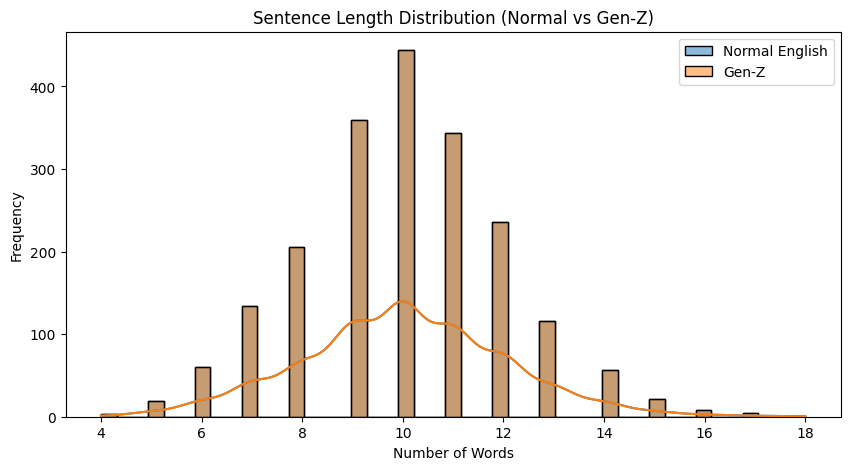

In [ ]:
# Sentence length (word count)
df["normal_len"] = df["normal"].apply(lambda x: len(x.split()))
df["genz_len"] = df["genz"].apply(lambda x: len(x.split()))

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df["normal_len"], label="Normal English", kde=True)
sns.histplot(df["genz_len"], label="Gen-Z", kde=True)
plt.legend()
plt.title("Sentence Length Distribution (Normal vs Gen-Z)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

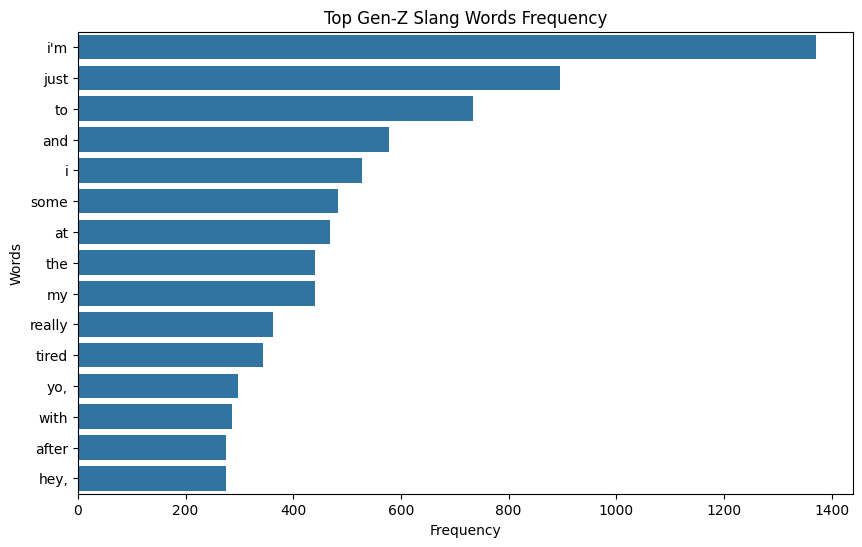

In [ ]:
from collections import Counter

genz_words = " ".join(df["genz"]).split()
counter = Counter(genz_words)

top_slang = counter.most_common(15)

words = [w[0] for w in top_slang]
freq = [w[1] for w in top_slang]

plt.figure(figsize=(10,6))
sns.barplot(x=freq, y=words)
plt.title("Top Gen-Z Slang Words Frequency")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

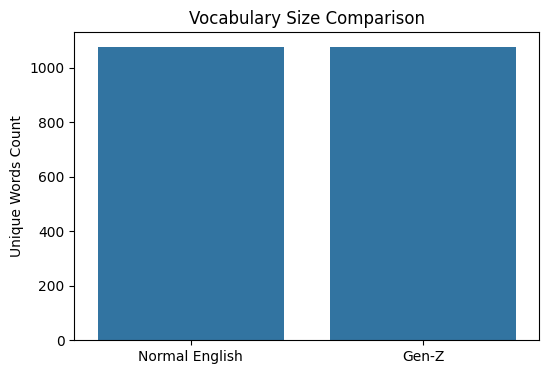

Normal vocab size: 1076
Gen-Z vocab size: 1076


In [ ]:
normal_vocab = set(" ".join(df["normal"]).split())
genz_vocab = set(" ".join(df["genz"]).split())

vocab_sizes = [len(normal_vocab), len(genz_vocab)]

plt.figure(figsize=(6,4))
sns.barplot(x=["Normal English", "Gen-Z"], y=vocab_sizes)
plt.title("Vocabulary Size Comparison")
plt.ylabel("Unique Words Count")
plt.show()

print("Normal vocab size:", len(normal_vocab))
print("Gen-Z vocab size:", len(genz_vocab))

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.1, random_state=42)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Train size:", len(train_df))
print("Test size:", len(test_df))

train_df.head()

Train size: 1809
Test size: 201


,normal,genz,normal_len,genz_len
0,"hey, i really like your new phone, it's awesome!","yo, your new phone is fire, so sick!",9,8
1,"i'm really tired today, i think i'll just rela...","i'm totally exhausted today, gonna just chill ...",11,10
2,"hey, do you want to grab some ice cream later?","yo, you down to snag some ice cream later?",10,9
3,"i'm chillin' at my place, vibing with some shows.",i'm just relaxing at home and watching some tv.,9,9
4,i'm just chillin' with my crew tonight.,i'm just going to hang out with some friends t...,7,10


In [ ]:
train_df["input_text"] = "translate english to genz: " + train_df["normal"]
train_df["target_text"] = train_df["genz"]

test_df["input_text"] = "translate english to genz: " + test_df["normal"]
test_df["target_text"] = test_df["genz"]

train_df[["input_text", "target_text"]].head()

,input_text,target_text
0,"translate english to genz: hey, i really like ...","yo, your new phone is fire, so sick!"
1,translate english to genz: i'm really tired to...,"i'm totally exhausted today, gonna just chill ..."
2,"translate english to genz: hey, do you want to...","yo, you down to snag some ice cream later?"
3,translate english to genz: i'm chillin' at my ...,i'm just relaxing at home and watching some tv.
4,translate english to genz: i'm just chillin' w...,i'm just going to hang out with some friends t...


In [ ]:
from transformers import T5Tokenizer

tokenizer = T5Tokenizer.from_pretrained("t5-small")

def tokenize_data(df, max_length=64):
    input_encodings = tokenizer(
        df["input_text"].tolist(),
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

    target_encodings = tokenizer(
        df["target_text"].tolist(),
        padding=True,
        truncation=True,
        max_length=max_length,
        return_tensors="pt"
    )

    return input_encodings, target_encodings

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/2.32k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

In [ ]:
train_inputs, train_targets = tokenize_data(train_df)
test_inputs, test_targets = tokenize_data(test_df)

print("Train input shape:", train_inputs["input_ids"].shape)
print("Train target shape:", train_targets["input_ids"].shape)

Train input shape: torch.Size([1809, 39])
Train target shape: torch.Size([1809, 32])


In [ ]:
from torch.utils.data import Dataset

class GenZDataset(Dataset):
    def __init__(self, inputs, targets):
        self.inputs = inputs
        self.targets = targets

    def __len__(self):
        return self.inputs["input_ids"].shape[0]

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.inputs.items()}
        item["labels"] = self.targets["input_ids"][idx]
        return item

train_dataset = GenZDataset(train_inputs, train_targets)
test_dataset = GenZDataset(test_inputs, test_targets)

print("Train dataset size:", len(train_dataset))
print("Test dataset size:", len(test_dataset))

Train dataset size: 1809
Test dataset size: 201


In [ ]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./genz_model",
    learning_rate=5e-5,
    per_device_train_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    logging_steps=100,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    report_to="none"
)

In [ ]:
# Strong Slang Map
strong_slang_map = {
    "honestly": ["ngl", "no cap"],
    "stylish outfit": ["drip", "fit"],
    "very good": ["fire", "ate", "slayed"],
    "cool energy": ["aura", "main character energy"],
    "average": ["mid"],
    "subtle": ["lowkey"],
    "obvious": ["highkey"],
    "friend": ["bro", "homie"],
    "ignored suddenly": ["ghosted"],
    "confident charm": ["rizz"],
    "focus": ["lock in"],
    "overworked / doomed": ["cooked"],
    "excited": ["hyped"],
    "outdated": ["cheugy"],
    "good vibe": ["bop"]
}

rows = []

for _, row in df.iterrows():
    normal = row["normal"]
    genz = row.get("genz", "")

    # English → Gen Z
    for eng, slang_list in strong_slang_map.items():
        if eng in normal:
            for slang in slang_list:
                rows.append({
                    "normal": normal,
                    "genz": normal.replace(eng, slang)
                })

    # Gen Z → English
    for eng, slang_list in strong_slang_map.items():
        for slang in slang_list:
            if slang in genz:
                rows.append({
                    "normal": genz.replace(slang, eng),
                    "genz": genz
                })

strong_df = pd.DataFrame(rows)

df_final = pd.concat([df, strong_df]).drop_duplicates().reset_index(drop=True)

print("Strong samples added:", len(strong_df))
print("Final dataset size:", len(df_final))

Strong samples added: 792
Final dataset size: 2801


In [ ]:
augmented_data = []

for _, row in df.iterrows():
    normal = row["normal"]

    for word, slang_list in strong_slang_map.items():
        if word in normal:
            for slang in slang_list:
                genz_sentence = normal.replace(word, slang)
                augmented_data.append({
                    "normal": normal,
                    "genz": genz_sentence
                })

aug_df = pd.DataFrame(augmented_data)

print("New Gen-Z sentences created:", len(aug_df))

df_new = pd.concat([df, aug_df]).drop_duplicates()
print("Old dataset size:", len(df))
print("New dataset size:", len(df_new))


New Gen-Z sentences created: 347
Old dataset size: 2010
New dataset size: 2357


In [ ]:
from transformers import T5ForConditionalGeneration

model = T5ForConditionalGeneration.from_pretrained("t5-small")
print("Model loaded")

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

Model loaded


In [ ]:
train_df3, test_df3 = train_test_split(df_new, test_size=0.1, random_state=42)

train_df3["input_text"] = "translate english to genz: " + train_df3["normal"]
train_df3["target_text"] = train_df3["genz"]

test_df3["input_text"] = "translate english to genz: " + test_df3["normal"]
test_df3["target_text"] = test_df3["genz"]

train_inputs3, train_targets3 = tokenize_data(train_df3)
train_dataset3 = GenZDataset(train_inputs3, train_targets3)

trainer3 = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset3,
)

trainer3.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Step,Training Loss
100,1.935152
200,1.014949
300,0.865814
400,0.774476
500,0.694301
600,0.654660
700,0.620781
800,0.639482
900,0.598780
1000,0.578866


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:668: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1330, training_loss=0.7744992205971166, metrics={'train_runtime': 4402.0078, 'train_samples_per_second': 2.409, 'train_steps_per_second': 0.302, 'total_flos': 109329477304320.0, 'train_loss': 0.7744992205971166, 'epoch': 5.0})

In [ ]:
def translate_to_genz(sentence):
    input_text = "translate english to genz: " + sentence
    inputs = tokenizer(
        input_text,
        return_tensors="pt",
        truncation=True,
        padding=True
    )

    outputs = model.generate(
        **inputs,
        max_length=50,
        num_beams=4,
        early_stopping=True
    )

    return tokenizer.decode(outputs[0], skip_special_tokens=True)

print("translate_to_genz() function loaded")

translate_to_genz() function loaded


In [ ]:
test_sentences = [
    "this movie was very good",
    "i am very tired today",
    "he is my friend",
    "i am really excited",
    "this food is very good",
]

for s in test_sentences:
    print("Normal:", s)
    print("Gen-Z :", translate_to_genz(s))
    print("-" * 50)

Normal: this movie was very good
Gen-Z : i loved this movie.
--------------------------------------------------
Normal: i am very tired today
Gen-Z : i'm hella drained today.
--------------------------------------------------
Normal: he is my friend
Gen-Z : i think i'm going to do well.
--------------------------------------------------
Normal: i am really excited
Gen-Z : i'm really hyped.
--------------------------------------------------
Normal: this food is very good
Gen-Z : hey, this food is really good.
--------------------------------------------------


In [ ]:
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

smoothie = SmoothingFunction().method4

references = []
predictions = []

for _, row in test_df3.iterrows():
    reference = row["genz"].split()
    prediction = translate_to_genz(row["normal"]).split()

    references.append([reference])
    predictions.append(prediction)

bleu_score_final = corpus_bleu(
    references,
    predictions,
    smoothing_function=smoothie
)

print("FINAL BLEU SCORE:", bleu_score_final)

FINAL BLEU SCORE: 0.4544510298176452


In [ ]:
# English -> Gen Z
eng_to_genz = {
    "honestly": ["ngl", "no cap"],
    "stylish outfit": ["drip", "fit"],
    "very good": ["fire", "ate", "slayed"],
    "cool energy": ["aura", "main character energy"],
    "average": ["mid"],
    "subtle": ["lowkey"],
    "obvious": ["highkey"],
    "friend": ["bro", "homie"],
    "ignored suddenly": ["ghosted"],
    "confident charm": ["rizz"],
    "focus": ["lock in"],
    "overworked / doomed": ["cooked"],
    "excited": ["hyped"],
    "outdated": ["cheugy"],
    "good vibe": ["bop"]
}

# Gen Z -> English
genz_to_eng = {
    "lit":"very good",
    "ngl": "not gonna lie",
    "no cap": "not lying / honestly",
    "drip": "fashionable outfit",
    "fit": "outfit",
    "fire": "very good",
    "ate": "performed extremely well",
    "slayed": "did amazingly",
    "mid": "average",
    "lowkey": "subtle",
    "highkey": "very obvious",
    "aura": "personal vibe or energy",
    "main character energy": "confident and attention-grabbing",
    "ghosted": "suddenly stopped communication",
    "rizz": "charisma or flirting skill",
    "lock in": "focus seriously",
    "cooked": "exhausted or in trouble",
    "hyped": "excited",
    "cheugy": "outdated or trying too hard",
    "bop": "really good experience or song"
}

In [ ]:
def live_model_translate(sentence, direction="eng_to_genz"):
    sentence = sentence.lower()

    if direction == "eng_to_genz":
        # MODEL handles English -> GenZ
        return translate_to_genz(sentence)

    elif direction == "genz_to_eng":
        # Rule-based GenZ -> English
        output = sentence
        for slang, meaning in genz_to_eng.items():
            output = output.replace(slang, meaning)
        return output

In [ ]:
def explain_translation(input_sentence, output_sentence, slang_dict):
    mapping = {}

    for key, value in slang_dict.items():
        if key in input_sentence:
            mapping[key] = value

    return {
        "translated_word_count": len(mapping),
        "word_mapping": mapping
    }

In [ ]:
def slang_injector(output, slang_map):
    for word, slang_list in slang_map.items():
        if word in output:
            return output.replace(word, slang_list[0], 1)
    return output

In [ ]:
def live_test(sentence, direction="eng_to_genz"):
    output = live_model_translate(sentence, direction)

    if direction == "eng_to_genz":
        final_output = slang_injector(output, eng_to_genz)
        explanation = explain_translation(sentence, final_output, eng_to_genz)

    else:  # genz_to_eng
        final_output = output
        explanation = explain_translation(sentence, final_output, genz_to_eng)

    return {
        "input": sentence,
        "output": final_output,
        "details": explanation
    }

In [ ]:
live_test("this movie was very good and i am excited", "eng_to_genz")

{'input': 'this movie was very good and i am excited',
 'output': "i'm really hyped to see this movie.",
 'details': {'translated_word_count': 2,
  'word_mapping': {'very good': ['fire', 'ate', 'slayed'],
   'excited': ['hyped']}}}

In [ ]:
live_test("this movie was lit and i am hyped", "genz_to_eng")

{'input': 'this movie was lit and i am hyped',
 'output': 'this movie was very good and i am excited',
 'details': {'translated_word_count': 2,
  'word_mapping': {'lit': 'very good', 'hyped': 'excited'}}}